Data Cleaning and Processing

In [78]:
import pandas as pd
from rich.jupyter import display

# Read the dataset
df_players = pd.read_csv('data/2023_nba_player_stats.csv')
df_players = df_players.drop(columns=['PName', 'Team'])


In [79]:
df_players.head()

,POS,Age,GP,W,L,Min,PTS,FGM,FGA,FG%,...,REB,AST,TOV,STL,BLK,PF,FP,DD2,TD3,+/-
0,SF,25,74,52,22,2732.2,2225,727,1559,46.6,...,649,342,213,78,51,160,3691,31,1,470
1,C,29,66,43,23,2284.1,2183,728,1328,54.8,...,670,274,226,66,112,205,3706,39,1,424
2,PG,24,66,33,33,2390.5,2138,719,1449,49.6,...,569,529,236,90,33,166,3747,36,10,128
3,PG,24,68,33,35,2416.0,2135,704,1381,51.0,...,329,371,192,112,65,192,3425,3,0,149
4,PF,28,63,47,16,2023.6,1959,707,1278,55.3,...,742,359,246,52,51,197,3451,46,6,341


In [80]:
df_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 28 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   POS     534 non-null    str    
 1   Age     539 non-null    int64  
 2   GP      539 non-null    int64  
 3   W       539 non-null    int64  
 4   L       539 non-null    int64  
 5   Min     539 non-null    float64
 6   PTS     539 non-null    int64  
 7   FGM     539 non-null    int64  
 8   FGA     539 non-null    int64  
 9   FG%     539 non-null    float64
 10  3PM     539 non-null    int64  
 11  3PA     539 non-null    int64  
 12  3P%     539 non-null    float64
 13  FTM     539 non-null    int64  
 14  FTA     539 non-null    int64  
 15  FT%     539 non-null    float64
 16  OREB    539 non-null    int64  
 17  DREB    539 non-null    int64  
 18  REB     539 non-null    int64  
 19  AST     539 non-null    int64  
 20  TOV     539 non-null    int64  
 21  STL     539 non-null    int64  
 22  BLK     539 n

In [81]:
# Cleaning NaN values

count_nan_df_players = df_players.isnull().sum()
count_nan_df_players

POS     5
Age     0
GP      0
W       0
L       0
Min     0
PTS     0
FGM     0
FGA     0
FG%     0
3PM     0
3PA     0
3P%     0
FTM     0
FTA     0
FT%     0
OREB    0
DREB    0
REB     0
AST     0
TOV     0
STL     0
BLK     0
PF      0
FP      0
DD2     0
TD3     0
+/-     0
dtype: int64

In [82]:
df_players['POS'] = df_players['POS'].fillna('UNKNOWN')
df_players['POS'].value_counts()

POS
SG         96
C          78
SF         77
PG         77
PF         74
F          66
G          66
UNKNOWN     5
Name: count, dtype: int64

In [83]:
# Cleaning: Remove unusual positions

df_players.drop(df_players[(df_players['POS']=='F') | (df_players['POS']=='G') | (df_players['POS']=='UNKNOWN')].index, inplace=True)

df_players['POS'].value_counts()

POS
SG    96
C     78
SF    77
PG    77
PF    74
Name: count, dtype: int64

Splitting the training and testing sets

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_players['POS_encoded'] = le.fit_transform(df_players['POS'])

# X: input features of yourself
X = df_players.drop(columns=['POS', 'POS_encoded'])
# Y: target
y = df_players['POS_encoded']

# Stratify: make the results distribute equally & not just by luck
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=22)

Build Pipeline for training

In [85]:
from sklearn.pipeline import Pipeline
from category_encoders.target_encoder import TargetEncoder
from xgboost import XGBClassifier

# Target Encoder: pre-processing procedure to transform categorial dataset into numeric
# XGBClassifier: make sure results not too random
estimators = [
    ('clf', XGBClassifier(random_state=22))
]

# Use pipeline to feed the model more efficient
pipe = Pipeline(steps=estimators)
pipe


,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None


Hyperparameter Tuning

In [86]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

search_space = {
    'clf__max_depth': Integer(2, 8),
    'clf__learning_rate': Real(0.001, 1.0, prior='log-uniform'),
    'clf__subsample': Real(0.5, 1.0),
    'clf__colsample_bytree': Real(0.5, 1.0),
    'clf__colsample_bylevel': Real(0.5, 1.0),
    'clf__colsample_bynode': Real(0.5, 1.0),
    'clf__reg_alpha': Real(0.0, 10.0),
    'clf__reg_lambda': Real(0.0, 10.0),
    'clf__gamma': Real(0.0, 10.0)
}

opt = BayesSearchCV(pipe, search_space, cv=3, n_iter=10, scoring='roc_auc_ovr', random_state=22)


Train the XGBoost Model

In [87]:
opt.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,search_spaces,"{'clf__colsample_bylevel': Real(low=0.5,...m='normalize'), 'clf__colsample_bynode': Real(low=0.5,...m='normalize'), 'clf__colsample_bytree': Real(low=0.5,...m='normalize'), 'clf__gamma': Real(low=0.0,...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,10
,scoring,'roc_auc_ovr'
,fit_params,None
,n_jobs,1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,3


Evaluate Model and make predictions

In [88]:
opt.best_params_

OrderedDict([('clf__colsample_bylevel', 0.8443057138882495),
             ('clf__colsample_bynode', 0.8239330122533642),
             ('clf__colsample_bytree', 0.9140858711837179),
             ('clf__gamma', 1.2674736424542656),
             ('clf__learning_rate', 0.02605737493506273),
             ('clf__max_depth', 3),
             ('clf__reg_alpha', 0.20864285794979456),
             ('clf__reg_lambda', 5.612809400718688),
             ('clf__subsample', 0.7988293286054218)])

In [89]:
opt.best_score_

np.float64(0.791662450713387)

In [90]:
opt.score(X_test, y_test)

0.7659746808558354

In [91]:
y_pred = opt.predict(X_test)

y_pred

array([3, 4, 4, 1, 2, 0, 2, 4, 2, 4, 1, 4, 2, 2, 0, 0, 4, 4, 1, 0, 4, 4,
       2, 3, 0, 0, 3, 2, 4, 0, 0, 2, 1, 0, 4, 0, 1, 1, 3, 1, 4, 2, 0, 1,
       4, 2, 4, 3, 1, 0, 1, 0, 2, 4, 2, 4, 1, 0, 4, 4, 2, 0, 4, 4, 0, 4,
       1, 2, 0, 1, 4, 3, 1, 4, 4, 4, 2, 0, 1, 4, 4])

In [92]:
opt.predict_proba(X_test)

array([[0.12076169, 0.14940004, 0.08350163, 0.34114304, 0.30519357],
       [0.08077908, 0.11556876, 0.23741996, 0.2104412 , 0.35579103],
       [0.1367954 , 0.16706212, 0.21143478, 0.19902912, 0.28567857],
       [0.309637  , 0.31288067, 0.14186047, 0.12942407, 0.10619781],
       [0.04570946, 0.05823872, 0.5308344 , 0.10567944, 0.259538  ],
       [0.7019326 , 0.10196415, 0.04789241, 0.07886471, 0.06934611],
       [0.07986553, 0.2017756 , 0.30542225, 0.16696551, 0.24597113],
       [0.06770786, 0.07938369, 0.16777742, 0.19153365, 0.49359742],
       [0.08686252, 0.11822885, 0.3692319 , 0.15508585, 0.27059084],
       [0.21247551, 0.15718326, 0.17248248, 0.19153698, 0.26632178],
       [0.11132149, 0.31620485, 0.12172382, 0.19482565, 0.2559242 ],
       [0.07961213, 0.19360942, 0.10814209, 0.26125002, 0.35738635],
       [0.07245455, 0.07777256, 0.3925183 , 0.15060784, 0.30664676],
       [0.08915663, 0.15580505, 0.30182847, 0.19493176, 0.2582781 ],
       [0.2982275 , 0.19620505, 0.

In [93]:
predictions = [round(value) for value in y_pred]
predictions

[3,
 4,
 4,
 1,
 2,
 0,
 2,
 4,
 2,
 4,
 1,
 4,
 2,
 2,
 0,
 0,
 4,
 4,
 1,
 0,
 4,
 4,
 2,
 3,
 0,
 0,
 3,
 2,
 4,
 0,
 0,
 2,
 1,
 0,
 4,
 0,
 1,
 1,
 3,
 1,
 4,
 2,
 0,
 1,
 4,
 2,
 4,
 3,
 1,
 0,
 1,
 0,
 2,
 4,
 2,
 4,
 1,
 0,
 4,
 4,
 2,
 0,
 4,
 4,
 0,
 4,
 1,
 2,
 0,
 1,
 4,
 3,
 1,
 4,
 4,
 4,
 2,
 0,
 1,
 4,
 4]

Measure feature importance

In [94]:
opt.best_estimator_.steps

[('clf',
  XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=0.8443057138882495,
                colsample_bynode=0.8239330122533642,
                colsample_bytree=0.9140858711837179, device=None,
                early_stopping_rounds=None, enable_categorical=False,
                eval_metric=None, feature_types=None, feature_weights=None,
                gamma=1.2674736424542656, grow_policy=None, importance_type=None,
                interaction_constraints=None, learning_rate=0.02605737493506273,
                max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
                max_delta_step=None, max_depth=3, max_leaves=None,
                min_child_weight=None, missing=nan, monotone_constraints=None,
                multi_strategy=None, n_estimators=None, n_jobs=None,
                num_parallel_tree=None, ...))]

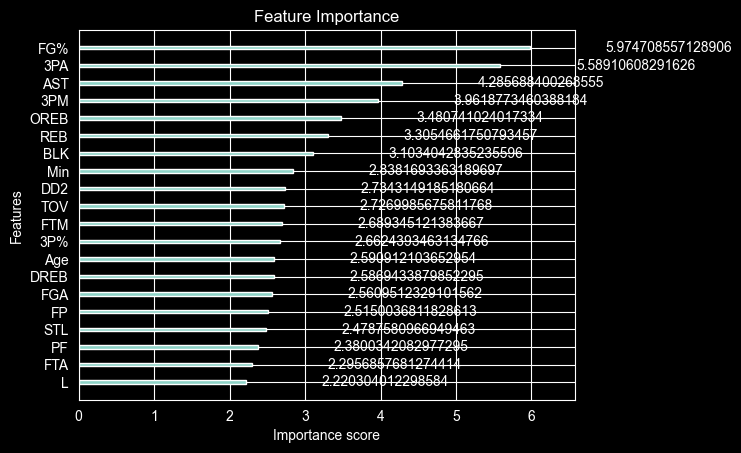

In [95]:
from xgboost import plot_importance

# xgboost_step = opt.best_estimator_.steps[1]
xgboost_model = opt.best_estimator_.named_steps['clf']

plot_importance(xgboost_model, max_num_features=20, importance_type='gain', title='Feature Importance')

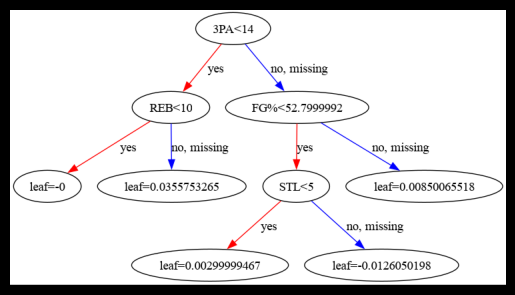

In [96]:
from xgboost import plot_tree

plot_tree(xgboost_model)

Confusion matrix

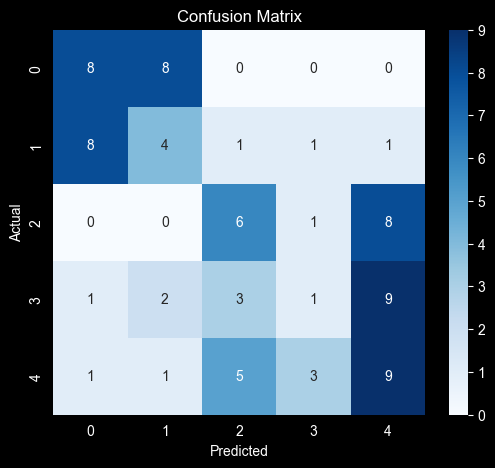

In [97]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, opt.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Accuracy and CV Score Validation

In [98]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Calculate accuracy score
best_model = opt.best_estimator_
# predictions = best_model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

# CV Accuracy Mean
model_accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy score: {((accuracy) * 100 ):.2f}%')

# cv_scores = cross_val_score(pipe, X_train, y_train, cv=4, scoring='accuracy')
# print(f'Accuracy score: {accuracy}')
# print(f'CV Accuracy mean: {cv_scores.mean()}')


Accuracy score: 34.57%
